In [ ]:
import warnings
from dataclasses import dataclass
from typing import Tuple, List
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    MinMaxScaler,
)
from sklearn.linear_model import (
    Lasso,
)
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')

#### 1. Answer the questions from the introduction

##### 1.1 Propose a new method to initialize cluster centroids for K-means. List the advantages and disadvantages of Forgy, Random Partition, and your own initializations.

The new method:

Advantages:
Forgy - <br>
Random Partition - <br>
My - <br>

Disadvantages:
Forgy - <br>
Random Partition - <br>
My - <br>

##### 1.2 Describe how you can use clustering to speed up the KNN model. Hint: what is kd-tree?

Kd-tree - is <br>
Using clustering to speed up the KNN model: <br>

#### 2. Introduction — make all the preprocessing staff from the previous lesson

In [261]:
# path: str = "data/two-sigma-connect-rental-listing-inquiries/{name}.json"
# train_df: pd.DataFrame = pd.read_json(
#     path.format(name="train"), convert_dates=["created"]
# )
# test_df: pd.DataFrame = pd.read_json(
#     path.format(name="test"), convert_dates=["created"]
# )
# csv from materials not from kaggle, test from materials has interest lvl col
path: str = "data/train_test_renthop/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(
    path.format(name="train"), parse_dates=[4], index_col=0,
)
train_df.name = "train_df"
test_df: pd.DataFrame = pd.read_csv(
    path.format(name="test"), parse_dates=[4], index_col=0,
)
test_df.name = "test_df"

In [262]:
# values: dict = {"low": 0, "medium": 1, "high": 2}
# train_df["interest_level"] = train_df["interest_level"].apply(lambda x: values[x])

In [263]:
# lower_limit: np.float64 = train_df["price"].quantile(0.01)
# upper_limit: np.float64 = train_df["price"].quantile(0.99)
# train_df.drop(
#     train_df[
#         (train_df["price"] >= upper_limit) | (train_df["price"] <= lower_limit)
#     ].index,
#     inplace=True,
# )

In [264]:
# features_list: list = [
#     "Elevator",
#     "CatsAllowed",
#     "HardwoodFloors",
#     "DogsAllowed",
#     "Doorman",
#     "Dishwasher",
#     "NoFee",
#     "LaundryinBuilding",
#     "FitnessCenter",
#     "Pre-War",
#     "LaundryinUnit",
#     "RoofDeck",
#     "OutdoorSpace",
#     "DiningRoom",
#     "HighSpeedInternet",
#     "Balcony",
#     "SwimmingPool",
#     "LaundryInBuilding",
#     "NewConstruction",
#     "Terrace",
# ]

In [265]:
for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: 
            x.replace('"', '').replace('[', '').replace(']', '').replace("'", '').replace(' ', '')
    )

features_list: list = []
for num, row in train_df.iterrows():
    features_list += row['features'].split(',')

features_list = [x for x in features_list if x]
features_list = [x.replace(' ', '') for x in features_list ]
cnt = Counter(features_list).most_common(20)
features_list = [x[0] for x in cnt if x]
for x in features_list:
    train_df[x] = train_df['features'].str.contains(x, regex=False).astype(int)
    test_df[x] = test_df['features'].str.contains(x, regex=False).astype(int)

base_features_list: list = ["bathrooms", "bedrooms", "interest_level"]
features: list = features_list + base_features_list

#### 3. Implement the next methods:

##### 3.1 K-means algorithm.

In [276]:
@dataclass
class K_Means():
    """
    K Neighbors Classifier
    Algorithm complexity (Fit): O(1)
    Algorithm complexity (Predict): O(n_test_samples * n_train_samples * n_features)
    """
    n_clusters: int = 8

    def fit():
        print()

    def predict():
        print()

##### 3.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

In [ ]:
cluster_model = KMeans(n_clusters=30, random_state=42)
cluster_model.fit(train_df[['latitude', 'longitude']])
train_df['cluster_label'] = cluster_model.predict(train_df[['latitude', 'longitude']])
test_df['cluster_label'] = cluster_model.predict(test_df[['latitude', 'longitude']])

##### 3.3 Compute Silhouette score and Distortion.

##### The **"Distortion"** - a local minimum of the following cost function.
##### $\sum_{n=1}^N \|\mathbf{x}_n - \boldsymbol{\mu}_{z_n}\|^2$
##### where $\boldsymbol{\mu}_k = \frac{1}{N_k}\sum_{n:z_n=k}\mathbf{x}_n$ is the k-cluster center and 
##### $z_n^* = \arg \min_k \| \mathbf{x}_n - \boldsymbol{\mu}_k \|^2$ is the closest cluster of $\mathbf{x}_n$.

In [ ]:
def distortion_score(
        X: pd.DataFrame, 
        sample_weights: list, 
        centers: list, 
        labels: list
    ):
    pass

##### The **"Silhouette" coefficient** is computed using the average intra-cluster distance (a) and the average distance to the nearest cluster (b) for each instance i. <br> We define the silhouette coefficient of an instance i as $` \text{sc}(i) = (b_i - a_i) / \max(a_i, b_i) `$. <br>*Source: [Hidden Markov models for malware classification](https://www.researchgate.net/publication/272017073_Hidden_Markov_models_for_malware_classification)*

![Hidden Markov models for malware classification](../misc/images/hidden_markov_models_for_malware_classification.png)
##### What does it mean? This coefficient varies between -1 and +1. <br>If it is +1, the instance is close to all members of its cluster and far from other clusters; <br>a value of 0 means it is close to a cluster boundary; <br>and a value of -1 means it may be in the wrong cluster. <br>(The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters - sklearn*) <br>Then it is possible to calculate the **silhouette score** of a clustering K as the average silhouette coefficient over all samples.

In [ ]:
def silhouette_score(X: pd.DataFrame, labels: list):
    pass

In [278]:
silhouette: pd.DataFrame = pd.DataFrame(columns=['model', 'train', 'test'])
silhouette.loc[len(silhouette)] = {
    'model' : 'Kmeans',
    'test' : round(
        silhouette_score(test_df[['latitude', 'longitude']], test_df['cluster_label']), 4
    ),
    'train' : round(
        silhouette_score(train_df[['latitude', 'longitude']], train_df['cluster_label']), 4
    )
} 
silhouette

,model,train,test
0,Kmeans,0.4698,0.4673


In [ ]:
# distortion
cluster_model.inertia_

4.577892822197285

##### 3.4 Draw result with scatterplot, try to analyze it.

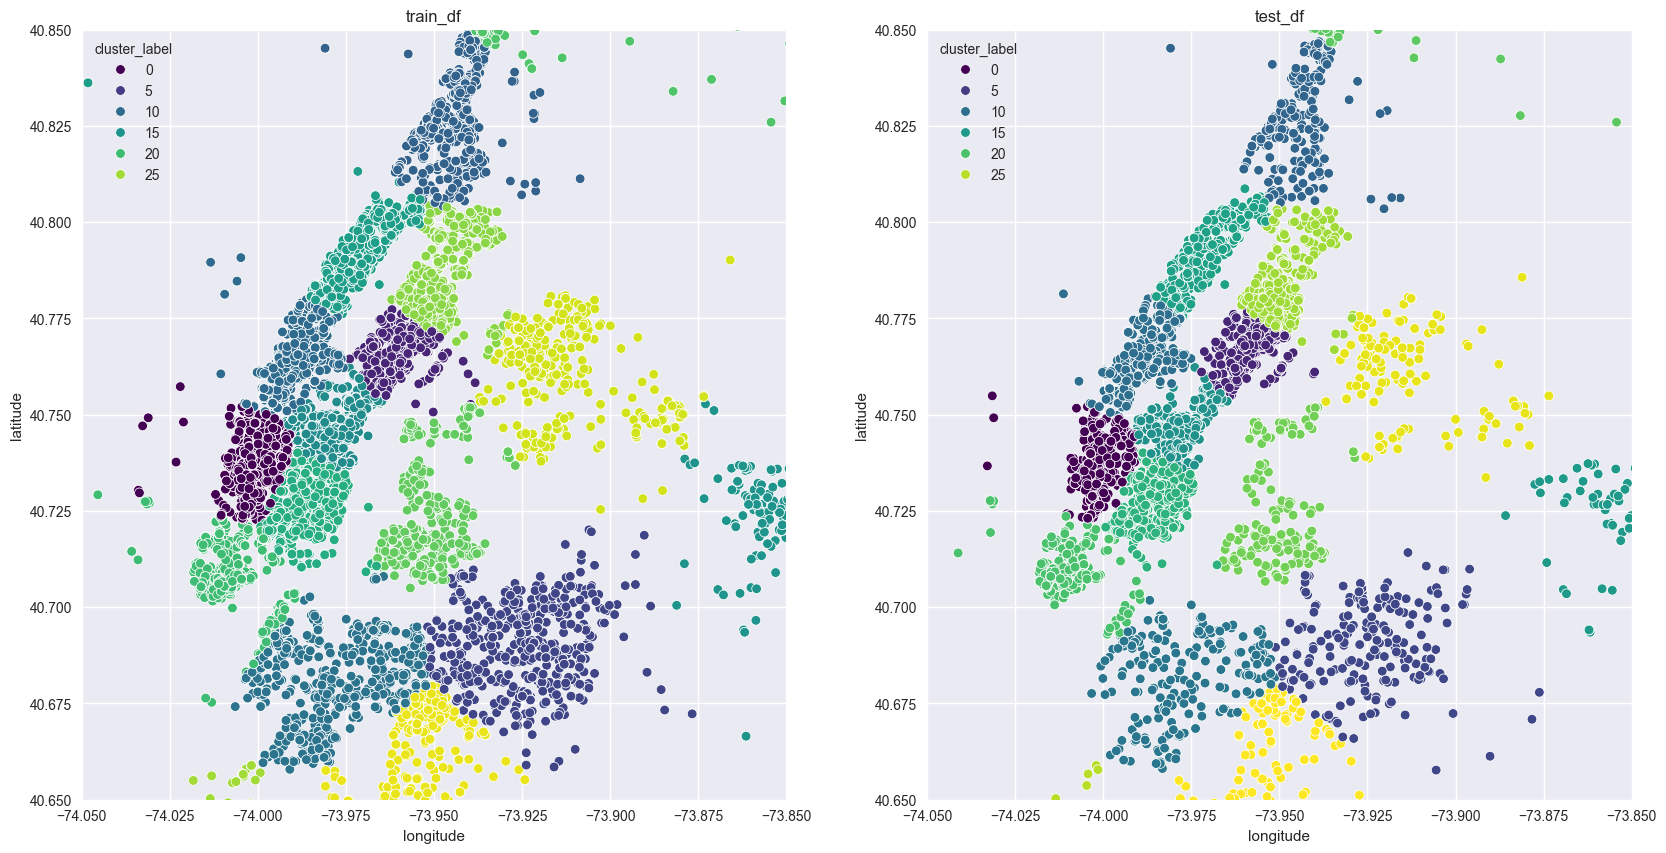

In [280]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
for num, df in enumerate((train_df, test_df)):
    sns.scatterplot(
        x=df['longitude'], 
        y=df['latitude'], 
        hue=df['cluster_label'], 
        ax=ax[num],
        palette='viridis'
    )
    ax[num].set(xlim=(-74.05,-73.85))
    ax[num].set(ylim=(40.65,40.85))
    ax[num].set(title=df.name)

##### 3.5 Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller

In [281]:
X_train: pd.DataFrame = train_df[features + ['cluster_label']]
y_train: pd.DataFrame = train_df["price"]

X_test: pd.DataFrame = test_df[features + ['cluster_label']]
y_test: pd.DataFrame = test_df["price"]

sc = MinMaxScaler()
X_train_norm = pd.DataFrame(sc.fit_transform(X=X_train))
X_test_norm = pd.DataFrame(sc.transform(X=X_test))

model = Lasso(random_state=42)
model.fit(X_train_norm, y_train)

y_pred_train = model.predict(X_train_norm)
y_pred_test = model.predict(X_test_norm)

display(
    mean_absolute_error(y_true=y_train, y_pred=y_pred_train),
    mean_absolute_error(y_true=y_test, y_pred=y_pred_test)
)

display(
    root_mean_squared_error(y_true=y_train, y_pred=y_pred_train),
    root_mean_squared_error(y_true=y_test, y_pred=y_pred_test)
)

display(
    r2_score(y_true=y_train, y_pred=y_pred_train),
    r2_score(y_true=y_test, y_pred=y_pred_test)
)

679.3550179855112

667.6030136026136

992.1394832451942

959.6435716510587

0.6157553939553482

0.6116393203415483

##### 3.6 Print the feature importance as the feature weight from the Lasso.

In [283]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features + ['cluster_label']
feature_importance['ftr_imp'] = model.coef_

feature_importance = feature_importance.sort_values(by='ftr_imp', key=abs)
feature_importance

,name,ftr_imp
2,CatsAllowed,-0.000000
15,Balcony,-0.000000
12,OutdoorSpace,-29.355848
9,Pre-War,-38.085806
18,NewConstruction,-44.052604
16,SwimmingPool,52.749926
3,DogsAllowed,62.127898
11,RoofDeck,-90.085070
6,NoFee,-97.972984
1,HardwoodFloors,-125.660616


##### 3.7 Import K-means from sklearn and compare results.

#### 4. Implement the next method:

##### 4.1 DBScan algorithm.

In [273]:
@dataclass
class DBSCAN():
    pass

##### 4.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

##### 4.3 Compute Silhouette score and Distortion.

##### 4.4 Draw result with scatterplot, try to analyze it.

##### 4.5 Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller

##### 4.6 Print the feature importance as the feature weight from the Lasso.

##### 4.7 Import DBScan from sklearn and compare results.

#### 5. Implement the next method:

##### 5.1 AgglomerativeClustering algorithm.

In [274]:
# algorithm is not mandatory for you, you can import it from sklearn.

##### 5.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

##### 5.3 Compute Silhouette score and Distortion.

##### 5.4 Draw result with scatterplot, try to analyze it.

##### 5.5 Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller

##### 5.6 Print the feature importance as the feature weight from the Lasso.

##### 5.7 Import AgglomerativeClustering from sklearn and compare results.

#### 6. Implement the next method:

##### 6.1 Gaussian Mixture algorithm.

In [275]:
@dataclass
class GaussianMixture():
    pass

##### 6.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

##### 6.3 Compute Silhouette score and Distortion.

##### 6.4 Draw result with scatterplot, try to analyze it.

##### 6.5 Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller

##### 6.6 Print the feature importance as the feature weight from the Lasso.

##### 6.7 Import Gaussian Mixture from sklearn and compare results.

#### 7. Try all these algorithms with different sets of features that might be more efficient in clustering.<br> In the checklist will cluster for 3 features — bedrooms, bathrooms and interest_level.

#### 8. Compare the results with the complexity, speed and accuracy of these methods.

#### Bonus:

##### B1. For additional task, you can try different models instead of Lasso.

##### B2. You could apply optimization methods to hyperparameters of algorithms, e.g. to find the optimal number of clusters.

##### B3. You could apply optimization methods to hyperparameters of algorithms, e.g. to find the optimal number of clusters.

#### * Sources
- Part 3.3 Silhouette coefficient [Hidden Markov models for malware classification](https://www.researchgate.net/publication/272017073_Hidden_Markov_models_for_malware_classification)